# Классификация CC50 > median

Здесь та же логика, но для `CC50 > 411.039342`.

Порог тоже фиксирован заранее, так что лишняя конфигурируемость здесь не нужна.

In [10]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

from src.common.config import RESULTS_DIR, TASKS
from src.common.data import find_dataset_path, load_dataset
from src.common.preprocessing import prepare_task_data
from src.common.training import run_regression_si_task, run_supervised_task

Matplotlib is building the font cache; this may take a moment.


## Настройки запуска

По умолчанию стоит полный режим `nested`. Если нужен быстрый прогон для проверки,
достаточно переключить `EVALUATION_STRATEGY` на `"holdout"`.

In [11]:
TASK_NAME = 'classification_cc50_gt_median'
EVALUATION_STRATEGY = 'nested'
MODELS = None
SKIP_CATBOOST = False
OUTER_FOLDS = 5
INNER_FOLDS = 3
TEST_SIZE = 0.2
RANDOM_SEED = 42
TOP_K_IMPORTANCE = 20

task = TASKS[TASK_NAME]
dataframe = load_dataset(find_dataset_path())
prepared = prepare_task_data(dataframe, task)

print(f'Задача: {task.title}')
print(f'Матрица признаков: {prepared["X"].shape}')
print(f'Число признаков после фильтрации: {len(prepared["feature_columns"])}')
print(f'Статус проверки на утечку: {prepared["leakage_report"]["status"]}')

Задача: Классификация: CC50 > 411.039342
Матрица признаков: (1001, 210)
Число признаков после фильтрации: 210
Статус проверки на утечку: passed


## Быстрый срез по таргету

Перед обучением полезно один раз посмотреть, что именно мы подаём в модель.

In [12]:
target_frame = (
    prepared['y']
    .value_counts()
    .sort_index()
    .rename_axis('label')
    .reset_index(name='count')
)
target_frame['share'] = target_frame['count'] / target_frame['count'].sum()
display(target_frame)

,label,count,share
0,0,500,0.4995
1,1,501,0.5005


## Запуск эксперимента

Эта ячейка пересчитывает результаты, пишет артефакты в `results/` и обновляет текстовый отчёт в `reports/`.

In [5]:
args = SimpleNamespace(
    evaluation_strategy=EVALUATION_STRATEGY,
    models=MODELS,
    skip_catboost=SKIP_CATBOOST,
    outer_folds=OUTER_FOLDS,
    inner_folds=INNER_FOLDS,
    test_size=TEST_SIZE,
    random_seed=RANDOM_SEED,
    top_k_importance=TOP_K_IMPORTANCE,
)

summary = run_supervised_task(task, args)
summary

2026-04-20 16:32:58,286 | INFO | Running classification_cc50_gt_median with models: ['dummy', 'logistic_regression', 'knn', 'svc', 'random_forest', 'extra_trees', 'gradient_boosting', 'catboost']
2026-04-20 16:32:58,286 | INFO | Evaluating model dummy
2026-04-20 16:32:58,789 | INFO | Evaluating model logistic_regression
2026-04-20 16:33:03,063 | INFO | Evaluating model knn
2026-04-20 16:33:09,117 | INFO | Evaluating model svc
2026-04-20 16:33:30,446 | INFO | Evaluating model random_forest
2026-04-20 16:40:29,658 | INFO | Evaluating model extra_trees
2026-04-20 16:43:20,792 | INFO | Evaluating model gradient_boosting
2026-04-20 16:46:56,616 | INFO | Evaluating model catboost
2026-04-20 17:00:35,454 | INFO | Finished classification_cc50_gt_median. Winner: catboost


{'task_name': 'classification_cc50_gt_median',
 'title': 'Классификация: CC50 > 411.039342',
 'problem_type': 'classification',
 'target_column': 'CC50, mM',
 'threshold': 411.039342,
 'primary_metric': 'roc_auc',
 'evaluation_strategy': 'nested',
 'random_seed': 42,
 'data_contract_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/data_contract.json',
 'leaderboard_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/classification_cc50_gt_median/leaderboard.csv',
 'winner': {'task_name': 'classification_cc50_gt_median',
  'problem_type': 'classification',
  'target_column': 'CC50, mM',
  'primary_metric': 'roc_auc',
  'evaluation_strategy': 'nested',
  'model_name': 'catboost',
  'mode': 'direct',
  'fit_seconds': 818.7836970829521,
  'best_params_json': '{"depth": 6, "iterations": 200, "l2_leaf_reg": 3, "learning_rate": 0.03}',
  'roc_auc': 0.8517858415841584,
  'roc_auc_std': 0.0190199296169843

## Лидерборд

Сравнение разных моделей.

In [6]:
leaderboard = pd.read_csv(RESULTS_DIR / 'classification_cc50_gt_median' / 'leaderboard.csv')
display(leaderboard)

,task_name,problem_type,target_column,primary_metric,evaluation_strategy,model_name,mode,fit_seconds,best_params_json,roc_auc,roc_auc_std,f1,f1_std,balanced_accuracy,balanced_accuracy_std
0,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,catboost,direct,818.783697,"{""depth"": 6, ""iterations"": 200, ""l2_leaf_reg"":...",0.851786,0.019020,0.769629,0.017325,0.767218,0.019652
1,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,extra_trees,direct,171.075721,"{""class_weight"": ""balanced"", ""max_depth"": 8, ""...",0.847082,0.023706,0.766360,0.020289,0.754188,0.020604
2,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,random_forest,direct,419.210226,"{""class_weight"": ""balanced"", ""max_depth"": 8, ""...",0.841179,0.013723,0.760753,0.011830,0.753238,0.012631
3,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,gradient_boosting,direct,215.820819,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",0.839736,0.017482,0.747591,0.017393,0.744257,0.018767
4,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,svc,direct,21.327363,"{""C"": 1.0, ""class_weight"": null, ""gamma"": ""sca...",0.834065,0.022833,0.765597,0.019110,0.761208,0.016608
5,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,logistic_regression,direct,4.272739,"{""C"": 0.1, ""class_weight"": null}",0.825207,0.026883,0.750212,0.017645,0.740178,0.016039
6,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,knn,direct,6.052024,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""uniform""}",0.812587,0.025577,0.748146,0.029424,0.741238,0.033862
7,classification_cc50_gt_median,classification,"CC50, mM",roc_auc,nested,dummy,direct,0.500552,"{""strategy"": ""stratified""}",0.478495,0.027730,0.579912,0.071793,0.514495,0.023046


## Короткий разбор результата

In [7]:
winner = leaderboard.iloc[0]
baseline_rows = leaderboard[leaderboard['model_name'] == 'dummy']
baseline = baseline_rows.iloc[0] if not baseline_rows.empty else None

print(
    f"Победитель: {winner['model_name']} "
    f"({winner['mode']}), "
    f"основная метрика {winner['primary_metric']} = {winner[winner['primary_metric']]:.6f}."
)
if baseline is not None:
    print(
        f"Для сравнения dummy даёт {baseline[baseline['primary_metric']]:.6f} по той же метрике."
    )
print(f"Лучшие параметры: {winner['best_params_json']}")

Победитель: catboost (direct), основная метрика roc_auc = 0.851786.
Для сравнения dummy даёт 0.478495 по той же метрике.
Лучшие параметры: {"depth": 6, "iterations": 200, "l2_leaf_reg": 3, "learning_rate": 0.03}


## Что видно по важности признаков

In [ ]:
importance_path = RESULTS_DIR / 'classification_cc50_gt_median' / 'winner_feature_importance.csv'
if importance_path.exists():
    display(pd.read_csv(importance_path).head(15))

,feature,importance,abs_importance
0,NHOHCount,7.028840,7.028840
1,NumSaturatedHeterocycles,3.999191,3.999191
2,BCUT2D_MWLOW,3.746379,3.746379
3,PEOE_VSA7,2.919958,2.919958
4,BCUT2D_MRLOW,2.431482,2.431482
5,PEOE_VSA6,2.116564,2.116564
6,fr_NH2,2.082153,2.082153
7,EState_VSA3,2.030941,2.030941
8,BCUT2D_CHGLO,1.734924,1.734924
9,MolLogP,1.618514,1.618514


## Матрица ошибок

Для бинарных задач полезно смотреть не только на метрики, но и на тип ошибок.

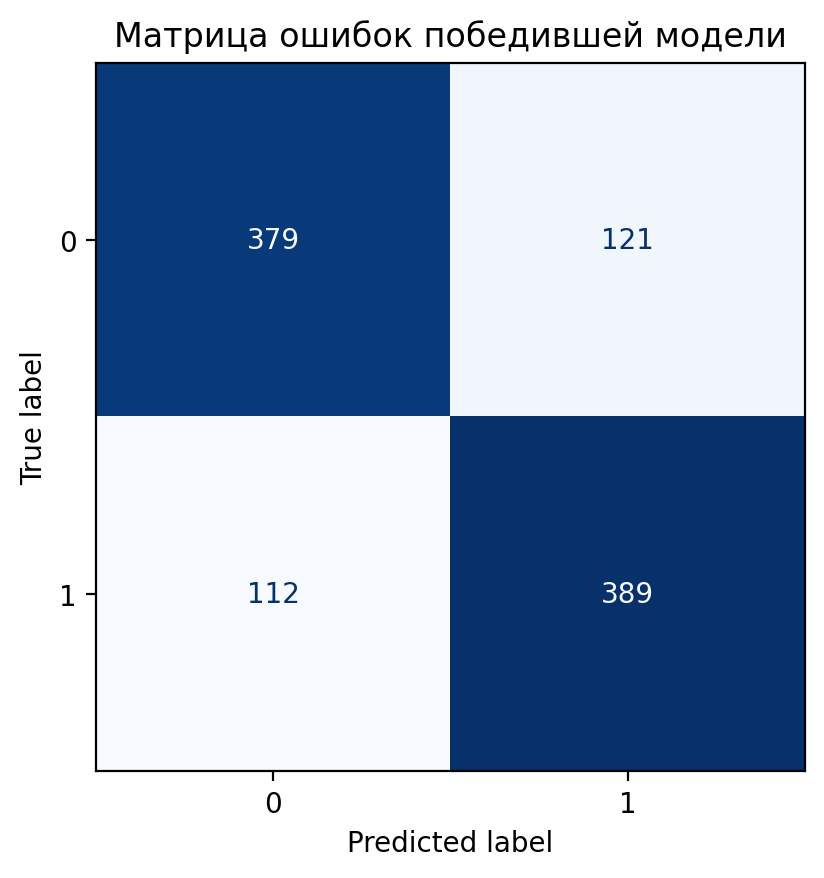

In [ ]:
confusion_path = RESULTS_DIR / 'classification_cc50_gt_median' / 'winner_confusion_matrix.png'
if confusion_path.exists():
    display(Image(filename=str(confusion_path)))

## Итог
TODO: написать почему именно эта модель победила и порассуждать почему в этой задаче именно она показывает хороший результат